# Difficulty Analysis

This notebook reads the day-2 analysis CSVs, compares interpretable difficulty scores against model/proxy errors, and lets you visualize easy and hard scenarios.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig_tailrisk_notebooks")

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tailrisk_mp.runtime import ensure_numpy_pickle_compat
from tailrisk_mp.scenario_viz import load_scenario_by_id, plot_scenario

ensure_numpy_pickle_compat()
pd.set_option("display.max_columns", 200)
print(f"Repo root: {REPO_ROOT}")

Repo root: /fs/nexus-projects/pc_driving/yaghoubi/tail-risk-motion-prediction


In [2]:
CONFIG = {
    "dataset": "av2",               # "waymo" or "av2"
    "split": "val",                 # "train" or "val"
    "tables_root": REPO_ROOT / "artifacts" / "day2" / "tables",
    "metrics_root": REPO_ROOT / "artifacts" / "day2" / "metrics",
    "score_column": "difficulty_v1",
    "error_column": None,            # None -> choose MTR error when available, else proxy
    "hard_quantile": 0.80,
    "easy_quantile": 0.20,
    "scenario_id": None,             # Optional explicit lookup
    "dataset_root_override": None,
    "view_radius": 90.0,
    "show_track_ids": False,
}

CONFIG

{'dataset': 'av2',
 'split': 'val',
 'tables_root': PosixPath('/fs/nexus-projects/pc_driving/yaghoubi/tail-risk-motion-prediction/artifacts/day2/tables'),
 'metrics_root': PosixPath('/fs/nexus-projects/pc_driving/yaghoubi/tail-risk-motion-prediction/artifacts/day2/metrics'),
 'score_column': 'difficulty_v1',
 'error_column': None,
 'hard_quantile': 0.8,
 'easy_quantile': 0.2,
 'scenario_id': None,
 'dataset_root_override': None,
 'view_radius': 90.0,
 'show_track_ids': False}

In [3]:
def analysis_table_path(config):
    return Path(config["tables_root"]) / f"{config['dataset']}_{config['split']}_analysis.csv"


def metadata_path(config):
    return REPO_ROOT / "artifacts" / "day2" / "metadata" / f"{config['dataset']}_style_metadata.json"


def load_analysis_frame(config):
    path = analysis_table_path(config)
    df = pd.read_csv(path)
    preferred_errors = ["mtr_minfde6", "mtr_minade6", "proxy_fde", "proxy_ade"]
    error_column = config["error_column"]
    if error_column is None:
        for candidate in preferred_errors:
            if candidate in df.columns and df[candidate].notna().any():
                error_column = candidate
                break
    if error_column is None:
        raise ValueError("No usable error column found in the selected table")
    return df, error_column, path


df, ERROR_COLUMN, table_path = load_analysis_frame(CONFIG)
metadata = json.loads(metadata_path(CONFIG).read_text()) if metadata_path(CONFIG).exists() else {}
summary_path = Path(CONFIG["metrics_root"]) / f"{CONFIG['dataset']}_{CONFIG['split']}_scores.csv"
score_summary = pd.read_csv(summary_path) if summary_path.exists() else pd.DataFrame()

print(f"Loaded: {table_path}")
print(f"Rows: {len(df):,}")
print(f"Using error column: {ERROR_COLUMN}")
if metadata:
    print(f"Style clusters: {metadata.get('style_cluster_count', 'unknown')}")
display(score_summary[score_summary["error_column"] == ERROR_COLUMN].sort_values("spearman", ascending=False).head(10))

Loaded: /fs/nexus-projects/pc_driving/yaghoubi/tail-risk-motion-prediction/artifacts/day2/tables/av2_val_analysis.csv
Rows: 464
Using error column: mtr_minfde6


,dataset,split,score_column,error_column,spearman,top20_error_capture,easy_mean_error,hard_mean_error,hard_over_easy_uplift
7,av2,val,kinematic_extremeness,mtr_minfde6,0.214684,0.365591,1.324560,2.504341,1.179781
8,av2,val,kalman_score,mtr_minfde6,0.167907,0.311828,1.319424,2.413811,1.094387
9,av2,val,trajectory_rarity_rank,mtr_minfde6,0.113772,0.279570,1.475694,1.805596,0.329902
10,av2,val,difficulty_v1,mtr_minfde6,0.037192,0.193548,1.402763,1.731200,0.328437
11,av2,val,style_rarity_rank,mtr_minfde6,-0.003169,0.236559,1.490917,1.574056,0.083140
12,av2,val,social_complexity,mtr_minfde6,-0.129640,0.139785,2.045832,1.379191,-0.666640
13,av2,val,neighbor_count_score,mtr_minfde6,-0.142071,0.139785,2.021772,1.339199,-0.682572


In [6]:
df

,dataset,split,scenario_id,center_objects_id,center_objects_type,trajectory_type,kalman_difficulty_2s,kalman_difficulty_4s,kalman_difficulty_6s,avg_speed,max_speed,avg_accel,max_accel,avg_jerk,heading_change_abs,displacement,path_length,curvature_proxy,neighbor_count_30m,min_neighbor_distance,inverse_min_neighbor_distance,max_closing_speed,min_ttc,inverse_min_ttc,proxy_ade,proxy_fde,proxy_miss_rate,style_cluster_id,trajectory_rarity,style_rarity,kalman_score,trajectory_rarity_rank,style_rarity_rank,neighbor_count_score,kinematic_extremeness,social_complexity,difficulty_v1,mtr_minade6,mtr_minfde6,mtr_miss_rate,mtr_brier_fde
0,av2,val,00450480-0bcd-46b9-a48b-5337d8c9d0a3,281880,1,1,3.218683,7.750482,13.094079,11.404687,12.081844,0.733410,1.751323,3.308162,0.214907,67.796982,67.799973,0.003170,17.0,8.926496,0.112026,0.0,inf,0.0,3.383866,8.380078,1.0,3,0.400057,1.448955,0.523861,0.670282,0.234816,0.947397,0.459276,0.431391,0.448941,0.389223,0.516814,0.0,0.769725
1,av2,val,02509248-5f65-4af6-bc9a-a88369bf32c2,2940,1,1,1.238202,2.357827,4.187929,15.339114,16.322758,0.542900,1.373615,3.012579,0.081777,91.042816,91.050232,0.000898,2.0,14.229320,0.070277,0.0,inf,0.0,2.872928,6.973195,1.0,3,0.400057,1.448955,0.202820,0.670282,0.234816,0.235900,0.483705,0.059016,0.361955,0.956946,1.826556,0.0,2.007650
2,av2,val,0253511d-47fd-446f-bacd-1f81047c24b9,108961,1,5,6.509085,18.642596,31.883770,7.131058,9.091616,1.306215,4.235868,6.764443,0.644749,44.083992,44.315342,0.014549,13.0,10.703421,0.093428,0.0,inf,0.0,8.266116,20.787971,1.0,2,2.515746,1.962864,0.905098,0.857918,0.895879,0.879067,0.498173,0.355773,0.651936,1.429535,2.483264,1.0,2.795730
3,av2,val,0324a545-ba68-4fdc-b4f8-aadf0c57d62f,59901,1,1,3.622757,7.973419,11.986397,9.917236,10.321422,0.475784,1.214762,2.162936,0.142107,58.543724,58.544621,0.002427,11.0,10.402198,0.096134,0.0,inf,0.0,2.358283,5.054088,1.0,3,0.400057,1.448955,0.492950,0.670282,0.234816,0.815076,0.345533,0.312227,0.390714,0.702166,1.321291,0.0,1.368463
4,av2,val,03418ae6-9c6c-4853-ace9-6b29fffc9930,67881,1,1,5.116903,17.742397,37.163242,6.785724,11.329609,2.452493,13.030712,9.153963,0.168992,40.878910,40.883896,0.004133,11.0,4.426206,0.225927,0.0,inf,0.0,7.224595,24.575657,1.0,2,0.400057,1.962864,0.948482,0.670282,0.895879,0.815076,0.546522,0.507628,0.655078,0.742564,1.849735,0.0,2.037247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
459,av2,val,fd1ba93b-5254-48ba-b411-833ef8ae77ff,13030,1,5,0.143012,1.054017,7.488498,2.504335,5.406265,0.977259,3.614259,2.070644,0.696936,15.269918,15.743414,0.044268,7.0,3.740513,0.267343,0.0,inf,0.0,2.011702,8.614529,1.0,5,2.515746,1.943743,0.340564,0.857918,0.755423,0.620390,0.226809,0.474740,0.578722,0.584807,1.047048,0.0,1.816715
460,av2,val,fdf22959-d90f-4a41-87d6-2ccafdba85e0,30584,1,1,1.280800,7.472100,19.103454,3.098438,6.617514,1.171436,7.382453,3.584663,0.230761,19.403051,19.430212,0.011876,3.0,21.829596,0.045809,0.0,inf,0.0,5.922873,19.284477,1.0,0,0.400057,1.462908,0.686009,0.670282,0.466377,0.312907,0.251944,0.047619,0.359056,0.752566,2.224042,1.0,2.630194
461,av2,val,fe036a44-01f4-4313-8a1b-40e95a15924b,158042,1,1,4.160523,11.408222,21.305528,7.945751,9.637889,0.766919,2.328877,3.331591,0.122672,47.488422,47.493443,0.002583,12.0,10.338110,0.096729,0.0,inf,0.0,4.173936,12.574766,1.0,0,0.400057,1.462908,0.731020,0.670282,0.466377,0.845445,0.344294,0.336934,0.454472,0.589841,1.191511,0.0,1.390580
462,av2,val,fe6463b3-1047-4f05-84db-84089fddc971,116827,1,1,1.887106,2.535332,5.503738,5.978120,7.314548,0.824165,2.097912,2.766912,0.166224,35.800529,35.830753,0.004639,13.0,5.865852,0.170478,0.0,inf,0.0,1.470792,3.030580,1.0,0,0.400057,1.462908,0.260304,0.670282,0.466377,0.879067,0.266360,0.471770,0.468697,0.552743,0.749931,0.0,1.517735


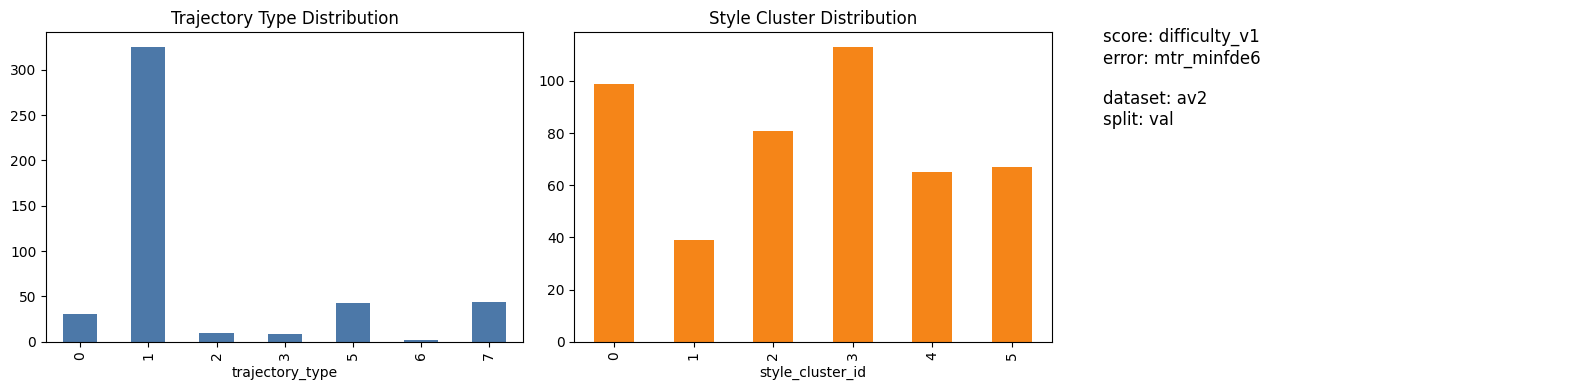

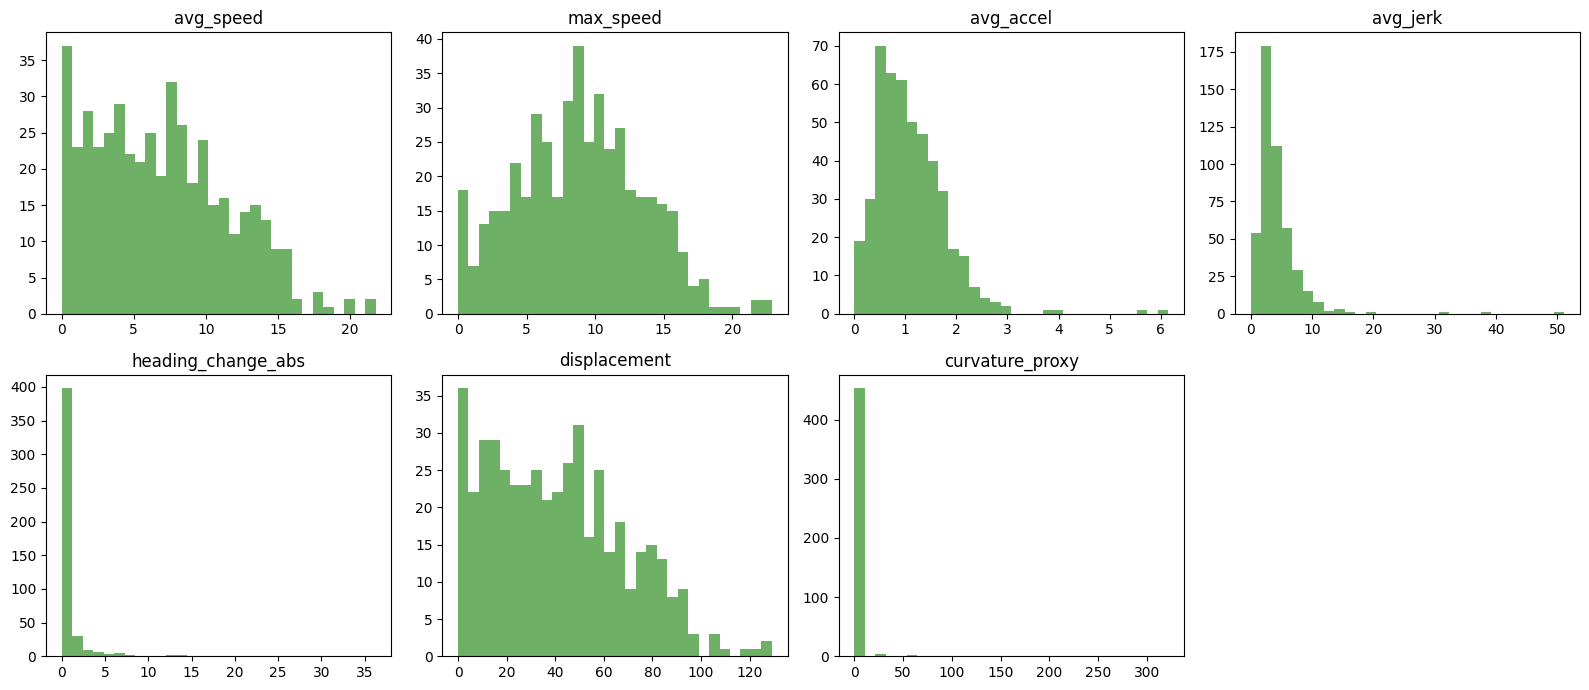

In [5]:
feature_cols = ["avg_speed", "max_speed", "avg_accel", "avg_jerk", "heading_change_abs", "displacement", "curvature_proxy"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df["trajectory_type"].value_counts().sort_index().plot.bar(ax=axes[0], color="#4c78a8")
axes[0].set_title("Trajectory Type Distribution")
axes[0].set_xlabel("trajectory_type")

df["style_cluster_id"].value_counts().sort_index().plot.bar(ax=axes[1], color="#f58518")
axes[1].set_title("Style Cluster Distribution")
axes[1].set_xlabel("style_cluster_id")

axes[2].axis("off")
axes[2].text(0.0, 0.9, f"score: {CONFIG['score_column']}\nerror: {ERROR_COLUMN}", fontsize=12)
axes[2].text(0.0, 0.7, f"dataset: {CONFIG['dataset']}\nsplit: {CONFIG['split']}", fontsize=12)
plt.tight_layout()

cluster_summary = pd.DataFrame(metadata.get('style_cluster_summary_eval') or metadata.get('style_cluster_summary_train') or [])
if not cluster_summary.empty:
    display(cluster_summary.sort_values('style_cluster_id'))

kin_cols = 4
kin_rows = int(np.ceil(len(feature_cols) / kin_cols))
fig, kin_axes = plt.subplots(kin_rows, kin_cols, figsize=(16, 3.5 * kin_rows))
kin_axes = np.atleast_1d(kin_axes).reshape(kin_rows, kin_cols)
for ax, column in zip(kin_axes.flat, feature_cols):
    ax.hist(df[column].dropna(), bins=30, color="#54a24b", alpha=0.85)
    ax.set_title(column)
for ax in kin_axes.flat[len(feature_cols):]:
    ax.axis("off")
plt.tight_layout()

/tmp/ipykernel_1234167/329259274.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_summary = df.assign(hardness_bin=bins).groupby("hardness_bin")[ERROR_COLUMN].agg(["count", "mean", "median"]).reset_index()


,hardness_bin,count,mean,median
0,easy,93,1.402763,1.351907
1,medium,278,1.730288,1.444078
2,hard,93,1.731200,1.412486


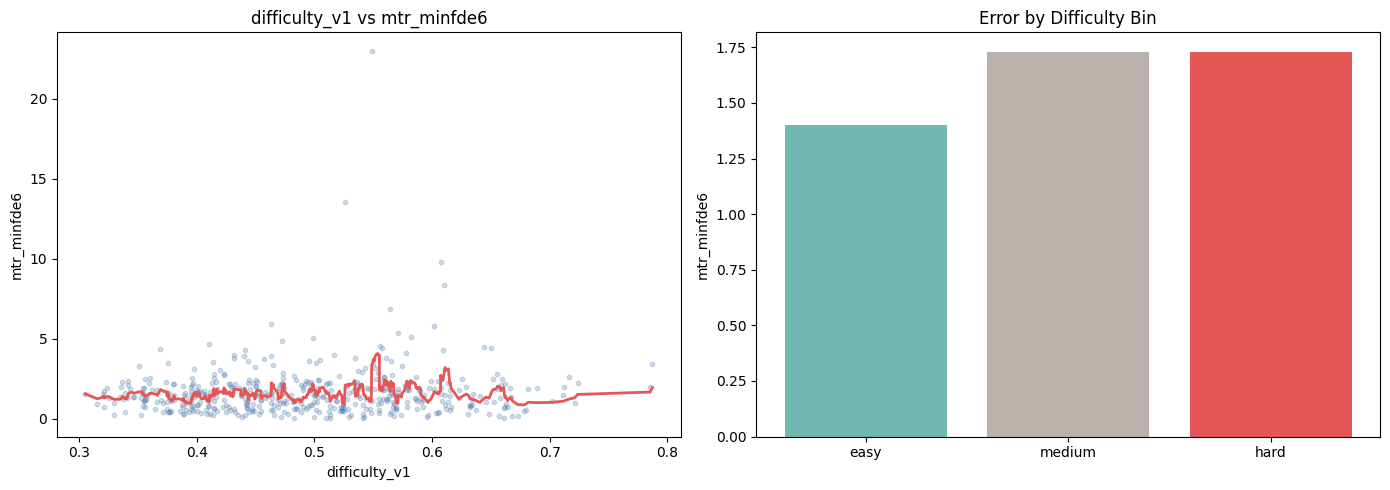

In [7]:
score_col = CONFIG["score_column"]
plot_df = df[[score_col, ERROR_COLUMN]].dropna().sort_values(score_col).reset_index(drop=True)
plot_df["rolling_error"] = plot_df[ERROR_COLUMN].rolling(window=max(len(plot_df) // 50, 10), min_periods=1).mean()

bins = pd.qcut(df[score_col], q=[0.0, CONFIG['easy_quantile'], CONFIG['hard_quantile'], 1.0], labels=["easy", "medium", "hard"], duplicates="drop")
bin_summary = df.assign(hardness_bin=bins).groupby("hardness_bin")[ERROR_COLUMN].agg(["count", "mean", "median"]).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample_size = min(len(plot_df), 4000)
sample_df = plot_df.sample(sample_size, random_state=42) if len(plot_df) > sample_size else plot_df
axes[0].scatter(sample_df[score_col], sample_df[ERROR_COLUMN], s=10, alpha=0.25, color="#4c78a8")
axes[0].plot(plot_df[score_col], plot_df["rolling_error"], color="#e45756", linewidth=2)
axes[0].set_title(f"{score_col} vs {ERROR_COLUMN}")
axes[0].set_xlabel(score_col)
axes[0].set_ylabel(ERROR_COLUMN)

axes[1].bar(bin_summary["hardness_bin"].astype(str), bin_summary["mean"], color=["#72b7b2", "#bab0ac", "#e45756"])
axes[1].set_title("Error by Difficulty Bin")
axes[1].set_ylabel(ERROR_COLUMN)
plt.tight_layout()

display(bin_summary)

,scenario_id,center_objects_id,difficulty_v1,mtr_minfde6,trajectory_type,style_cluster_id
227,8ca9d11d-dfe8-4750-ac23-58afc4d03cca,24727,0.787361,3.440154,6,2
191,73fbf7c4-ae53-49f5-a074-625ffc315d17,60808,0.785328,1.969003,2,2
448,fa8401af-1dbb-4f3c-a239-08fc2ca76ad5,83126,0.723718,2.229033,1,1
307,b46b5480-8e19-460b-aeee-f4f5ccc64a88,193514,0.721381,0.991087,0,1
264,a3428b3f-b16f-410e-8f2b-591f7d1cd264,50118,0.716386,2.622815,2,2
144,5bcd3a2e-497b-4124-8600-5030582197c4,48361,0.712069,1.999325,2,2
105,43b72af8-2b09-43bc-a52d-304760ce4784,83275,0.710954,1.477867,3,2
121,4f06cb23-37b5-4233-879f-2e69f3fbf55e,22339,0.701973,1.118708,0,1
416,eb8b2585-5fef-4786-a62d-e0bb14153276,211454,0.688823,1.910509,1,2
354,ceb9a5bb-f90a-4039-ac9e-bad321b88b32,79415,0.681763,1.864615,0,1


,scenario_id,center_objects_id,difficulty_v1,mtr_minfde6,trajectory_type,style_cluster_id
168,69e663f3-3580-44d7-bd13-a9ecc4f3192a,20467,0.305178,1.561895,1,3
166,672775db-a238-40a9-9df5-03a94c17e985,56469,0.315315,0.954523,1,3
6,0470b14d-42cd-4679-98f7-747965af66c0,1025,0.319885,1.532812,1,3
411,ea9d5f3e-b116-4b7d-8044-8f64647ed49f,56921,0.320764,1.732871,1,3
418,ec56f045-c1a7-43ee-97e6-7beb6710de98,256,0.321290,0.717402,1,3
149,6030a97a-151a-4975-896d-2a5b97e53891,4732,0.323318,1.914389,1,3
73,301e3c4a-7694-4457-bf8a-cb634c4e0d37,60541,0.325221,1.297952,1,3
101,426f4ee5-5dfa-43e3-b41d-b49d7746a33d,41403,0.329113,0.247979,1,3
55,22bd9b63-6ed1-4523-8a21-0c7453ec3237,51500,0.329733,0.990570,1,3
9,052d58dc-0e06-4067-a8c4-51591de3c943,26447,0.334450,1.354321,1,3


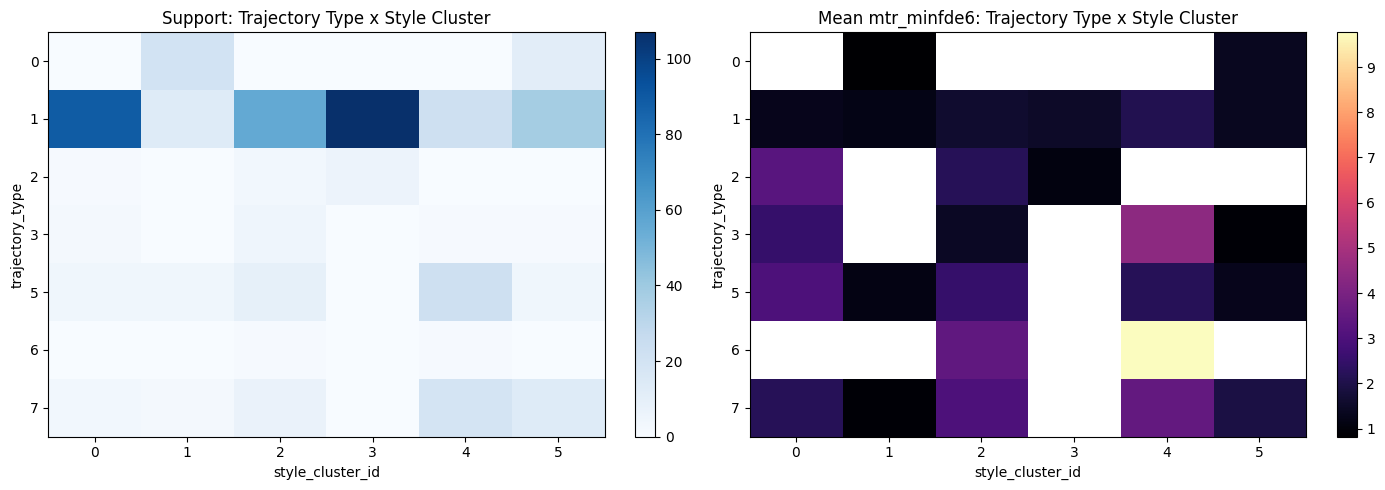

In [8]:
support = df.pivot_table(index="trajectory_type", columns="style_cluster_id", values="scenario_id", aggfunc="count", fill_value=0)
error_heatmap = df.pivot_table(index="trajectory_type", columns="style_cluster_id", values=ERROR_COLUMN, aggfunc="mean")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im0 = axes[0].imshow(support.values, aspect="auto", cmap="Blues")
axes[0].set_title("Support: Trajectory Type x Style Cluster")
axes[0].set_xlabel("style_cluster_id")
axes[0].set_ylabel("trajectory_type")
axes[0].set_xticks(range(len(support.columns)), support.columns)
axes[0].set_yticks(range(len(support.index)), support.index)
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(error_heatmap.fillna(np.nan).values, aspect="auto", cmap="magma")
axes[1].set_title(f"Mean {ERROR_COLUMN}: Trajectory Type x Style Cluster")
axes[1].set_xlabel("style_cluster_id")
axes[1].set_ylabel("trajectory_type")
axes[1].set_xticks(range(len(error_heatmap.columns)), error_heatmap.columns)
axes[1].set_yticks(range(len(error_heatmap.index)), error_heatmap.index)
plt.colorbar(im1, ax=axes[1], fraction=0.046)
plt.tight_layout()

hard_cut = df[score_col].quantile(CONFIG["hard_quantile"])
easy_cut = df[score_col].quantile(CONFIG["easy_quantile"])
hard_examples = df[df[score_col] >= hard_cut].sort_values([score_col, ERROR_COLUMN], ascending=[False, False]).head(10)
easy_examples = df[df[score_col] <= easy_cut].sort_values([score_col, ERROR_COLUMN], ascending=[True, False]).head(10)

display(hard_examples[["scenario_id", "center_objects_id", score_col, ERROR_COLUMN, "trajectory_type", "style_cluster_id"]])
display(easy_examples[["scenario_id", "center_objects_id", score_col, ERROR_COLUMN, "trajectory_type", "style_cluster_id"]])

In [10]:
candidate_scenario_id = CONFIG["scenario_id"]
if candidate_scenario_id is None:
    candidate_scenario_id = hard_examples.iloc[0]["scenario_id"]

scenario_split = CONFIG["split"]
if CONFIG["dataset"] == "waymo":
    scenario_split = "training" if scenario_split == "train" else "validation"
elif CONFIG["dataset"] == "av2":
    scenario_split = "train" if scenario_split == "train" else "val"

bundle = load_scenario_by_id(
    CONFIG["dataset"],
    candidate_scenario_id,
    split=scenario_split,
    dataset_root_override=CONFIG["dataset_root_override"],
)
print(f"Resolved scenario key: {bundle['scenario_key']}")
scenario = bundle["scenario"]
fig, ax = plot_scenario(
    scenario,
    dataset=CONFIG["dataset"],
    view_radius=CONFIG["view_radius"],
    show_track_ids=CONFIG["show_track_ids"],
)
plt.show()

display(df[df["scenario_id"] == candidate_scenario_id][["scenario_id", "center_objects_id", score_col, ERROR_COLUMN, "trajectory_type", "style_cluster_id"]].sort_values(score_col, ascending=False).head(20))

KeyError: '8ca9d11d-dfe8-4750-ac23-58afc4d03cca'